# Laboratorio #2 — Redes Neuronales Convolucionales (CNN vs. MLP en MNIST)

**CC3092 Deep Learning y Sistemas Inteligentes**

## 0. Imports y configuración

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", DEVICE)

pd.set_option("display.max_columns", None)
%matplotlib inline

Device: mps


## 1. Dataset

In [2]:
# Descarga MNIST en bruto (sin transform) para inspeccionar tipos/rangos originales
raw_train = datasets.MNIST(root="data", train=True, download=True)
raw_test = datasets.MNIST(root="data", train=False, download=True)
len(raw_train), len(raw_test)

(60000, 10000)

## 2. Exploración y preparación de los datos

### ¿Cuántas observaciones y cuántas clases tiene el dataset? ¿Están balanceadas?

In [3]:
n_train, n_test = len(raw_train), len(raw_test)
classes = raw_train.classes
print(f"Train: {n_train} imágenes | Test: {n_test} imágenes | Clases: {len(classes)} ({classes})")

train_counts = pd.Series(raw_train.targets.numpy()).value_counts().sort_index()
test_counts = pd.Series(raw_test.targets.numpy()).value_counts().sort_index()
pd.DataFrame({"train": train_counts, "test": test_counts})

Train: 60000 imágenes | Test: 10000 imágenes | Clases: 10 (['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine'])


,train,test
0,5923,980
1,6742,1135
2,5958,1032
3,6131,1010
4,5842,982
5,5421,892
6,5918,958
7,6265,1028
8,5851,974
9,5949,1009


**Hallazgos:** 60,000 imágenes de entrenamiento y 10,000 de test, 10 clases (dígitos 0-9).
Las clases están **razonablemente balanceadas**: cada dígito tiene entre ~9.9k y ~10.7k
observaciones en el set de tamaño 60k, sin ninguna clase dominante ni subrepresentada.

### ¿Cuál es la dimensión de cada imagen y qué rango de valores tienen los píxeles?

In [4]:
img0, label0 = raw_train[0]
arr0 = np.array(img0)
print("Tipo:", type(img0), "| Modo PIL:", img0.mode, "| Tamaño:", img0.size)
print("Shape como array:", arr0.shape, "| dtype:", arr0.dtype)
print("Rango de píxeles: [{}, {}]".format(arr0.min(), arr0.max()))

Tipo: <class 'PIL.Image.Image'> | Modo PIL: L | Tamaño: (28, 28)
Shape como array: (28, 28) | dtype: uint8
Rango de píxeles: [0, 255]


**Hallazgos:** cada imagen es de 28×28 píxeles, en escala de grises (1 canal). Los valores de
píxel son enteros `uint8` en el rango [0, 255].

### ¿Es necesario normalizar los valores de los píxeles?

Sí. Las redes entrenan mejor y de forma más estable con entradas de escala pequeña y centradas
cerca de 0 (gradientes mejor condicionados, convergencia más rápida). Se aplican dos pasos
estándar de `torchvision.transforms`:

1. `ToTensor()`: convierte `uint8 [0,255]` → `float32 [0,1]`.
2. `Normalize(mean=0.1307, std=0.3081)`: estandariza usando la media/desviación estándar
   conocidas de MNIST (calculadas sobre el train set completo), dejando los píxeles
   aproximadamente en media 0 y varianza 1.

In [5]:
MNIST_MEAN, MNIST_STD = 0.1307, 0.3081
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,)),
])

train_full = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root="data", train=False, download=True, transform=transform)

x_demo, y_demo = train_full[0]
print("Shape del tensor normalizado:", x_demo.shape, "| rango:", x_demo.min().item(), x_demo.max().item())

Shape del tensor normalizado: torch.Size([1, 28, 28]) | rango: -0.4242129623889923 2.821486711502075


### Visualización de ejemplos

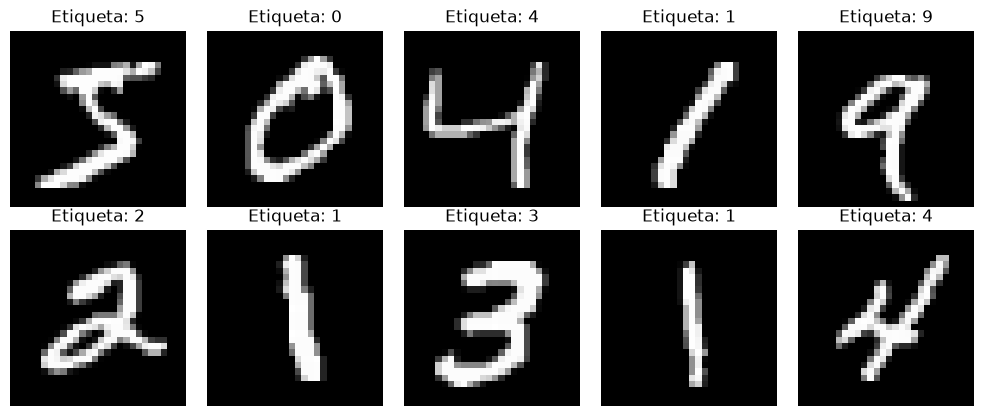

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.2))
for i, ax in enumerate(axes.flat):
    img, label = raw_train[i]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Etiqueta: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### División en entrenamiento y validación

In [7]:
# 90/10 sobre el train set (54,000 / 6,000); el test set (10,000) queda intacto hasta la evaluación final
n_val = int(0.1 * len(train_full))
n_tr = len(train_full) - n_val
generator = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_full, [n_tr, n_val], generator=generator)
len(train_ds), len(val_ds), len(test_ds)

(54000, 6000, 10000)

**Regla de aislamiento del test respetada:** `test_ds` no se usa en ninguna decisión de
arquitectura ni de hiperparámetros; solo se evalúa una vez en la sección 5.

## 3. Investigación: capas de PyTorch para la CNN

### `nn.Conv2d`
Aplica convolución 2D: desliza `out_channels` kernels de tamaño `kernel_size` sobre la
entrada, cada uno compartiendo sus pesos en toda la imagen (weight sharing). Parámetros
clave: `in_channels`, `out_channels`, `kernel_size`, `stride` (paso del kernel),
`padding` (relleno de borde para controlar el tamaño de salida). A diferencia de
`nn.Linear`, no conecta cada píxel con cada neurona: solo mira una ventana local
(campo receptivo), lo que preserva la estructura espacial 2D de la imagen.

In [8]:
conv = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
x = torch.randn(4, 1, 28, 28)  # batch de 4 imágenes MNIST
out = conv(x)
print("Entrada:", x.shape, "-> Salida:", out.shape)
print("Parámetros entrenables:", sum(p.numel() for p in conv.parameters()))

Entrada: torch.Size([4, 1, 28, 28]) -> Salida: torch.Size([4, 8, 28, 28])
Parámetros entrenables: 80


### `nn.MaxPool2d`
Reduce la resolución espacial tomando el valor máximo dentro de cada ventana
(`kernel_size`, con `stride` por defecto igual al kernel). No tiene parámetros
entrenables; resume la activación más fuerte de cada región, aportando invarianza a
pequeñas traslaciones y reduciendo el costo computacional de las capas siguientes.

In [9]:
pool = nn.MaxPool2d(kernel_size=2)
out_pool = pool(out)
print("Entrada:", out.shape, "-> Salida:", out_pool.shape)

Entrada: torch.Size([4, 8, 28, 28]) -> Salida: torch.Size([4, 8, 14, 14])


### `nn.AvgPool2d`
Igual que `MaxPool2d` pero promedia en vez de tomar el máximo dentro de cada ventana.
Suaviza la activación en vez de quedarse con el pico; útil cuando interesa la
intensidad promedio de una región y no solo su activación más fuerte (p. ej. como
pooling final antes de una capa totalmente conectada, en vez de aplanar todo el mapa).

In [10]:
avgpool = nn.AvgPool2d(kernel_size=2)
out_avg = avgpool(out)
print("Entrada:", out.shape, "-> Salida:", out_avg.shape)

Entrada: torch.Size([4, 8, 28, 28]) -> Salida: torch.Size([4, 8, 14, 14])


### `nn.BatchNorm2d`
Normaliza las activaciones de cada canal usando la media/varianza del mini-batch
actual, luego aplica un reescalado y desplazamiento aprendibles (`γ`, `β`). Parámetro
principal: `num_features` (= número de canales de entrada, debe igualar
`out_channels` de la capa conv anterior). Estabiliza y acelera el entrenamiento al
evitar que la distribución de activaciones se desplace demasiado entre capas
(internal covariate shift).

In [11]:
bn = nn.BatchNorm2d(num_features=8)
out_bn = bn(out)
print("Shape:", out_bn.shape, "| media por canal ~0:", out_bn.mean(dim=(0,2,3)).detach().numpy().round(3))

Shape: torch.Size([4, 8, 28, 28]) | media por canal ~0: [-0. -0.  0. -0.  0.  0.  0.  0.]


### `nn.Flatten`
Convierte un tensor multidimensional (p. ej. `[batch, C, H, W]`) en un vector 2D
`[batch, C*H*W]`, necesario para conectar la salida de las capas convolucionales con
capas `nn.Linear`. Parámetro `start_dim` (por defecto 1) controla desde qué eje se
aplana, preservando la dimensión de batch.

In [12]:
flatten = nn.Flatten()
out_flat = flatten(out_pool)
print("Entrada:", out_pool.shape, "-> Salida:", out_flat.shape)

Entrada: torch.Size([4, 8, 14, 14]) -> Salida: torch.Size([4, 1568])


### `nn.CrossEntropyLoss`
Pérdida estándar para clasificación multiclase. Combina internamente `log_softmax` +
`NLLLoss`: espera **logits crudos** (sin softmax aplicado) de forma `[batch, n_clases]`
y las etiquetas como enteros de clase `[batch]` (no one-hot). Parámetro relevante:
`weight` (para ponderar clases desbalanceadas, no necesario aquí dado el balance visto
en Batch 1).

In [13]:
criterion = nn.CrossEntropyLoss()
logits_demo = torch.randn(4, 10)          # 4 ejemplos, 10 clases (logits crudos)
labels_demo = torch.tensor([0, 3, 7, 1])  # etiquetas como enteros, no one-hot
loss_demo = criterion(logits_demo, labels_demo)
print("Loss:", loss_demo.item())

Loss: 3.956127166748047


### Tensor en PyTorch
Un tensor es un arreglo multidimensional (escalar, vector, matriz o de mayor orden)
que además de guardar datos numéricos rastrea las operaciones aplicadas sobre él
(autograd) para poder calcular gradientes automáticamente, y puede ejecutarse en
CPU, GPU (CUDA) o MPS de forma transparente.

### Campo receptivo (receptive field)
Es la región de la imagen de entrada que influye en el valor de una unidad de
activación dada, en cierta capa. En la primera capa conv es del tamaño del kernel
(p. ej. 3×3); al apilar capas conv/pool, el campo receptivo de las capas profundas
crece y termina cubriendo regiones mucho más grandes de la imagen original —
así la red combina información local en patrones cada vez más globales.

### ¿Por qué la CNN requiere menos parámetros que un MLP equivalente?
Una capa `nn.Linear` conecta **cada** píxel de entrada con **cada** neurona de salida:
para una imagen 28×28 y 128 neuronas ocultas, eso son `28*28*128 ≈ 100k` pesos solo en
la primera capa. Una capa `nn.Conv2d` reutiliza el **mismo** kernel pequeño (p. ej.
3×3) en toda la imagen (weight sharing) y cada salida solo depende de una ventana
local (conectividad local) — un `Conv2d(1, 8, kernel_size=3)` tiene apenas
`8*(1*3*3+1) = 80` parámetros sin importar el tamaño de la imagen. Esa reutilización
también actúa como regularización estructural: la misma detección de bordes/texturas
es válida en cualquier posición de la imagen.

## 4. Construcción y entrenamiento de las arquitecturas

### Definición de los modelos

In [14]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes=(128, 64), activation=nn.ReLU, dropout=0.0):
        super().__init__()
        layers = [nn.Flatten()]
        in_dim = 28 * 28
        for h in hidden_sizes:
            layers += [nn.Linear(in_dim, h), activation()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class CNN(nn.Module):
    def __init__(self, conv_channels=(16, 32), fc_hidden=64, activation=nn.ReLU,
                 dropout=0.0, use_batchnorm=True, pool="max"):
        super().__init__()
        Pool = nn.MaxPool2d if pool == "max" else nn.AvgPool2d
        conv_layers = []
        in_ch = 1
        for out_ch in conv_channels:
            conv_layers.append(nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1))
            if use_batchnorm:
                conv_layers.append(nn.BatchNorm2d(out_ch))
            conv_layers += [activation(), Pool(kernel_size=2)]
            in_ch = out_ch
        self.conv = nn.Sequential(*conv_layers)

        spatial = 28 // (2 ** len(conv_channels))
        flat_dim = in_ch * spatial * spatial
        fc_layers = [nn.Flatten(), nn.Linear(flat_dim, fc_hidden), activation()]
        if dropout > 0:
            fc_layers.append(nn.Dropout(dropout))
        fc_layers.append(nn.Linear(fc_hidden, 10))
        self.fc = nn.Sequential(*fc_layers)

    def forward(self, x):
        return self.fc(self.conv(x))


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### Datasets y DataLoaders

In [15]:
def make_loaders(batch_size):
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

### Ciclo de entrenamiento genérico

In [16]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.set_grad_enabled(is_train):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            all_preds.append(logits.argmax(dim=1).cpu())
            all_labels.append(yb.cpu())
    avg_loss = total_loss / len(loader.dataset)
    preds = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    return avg_loss, preds, labels


def train_model(model, train_loader, val_loader, optimizer, epochs):
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": []}
    for epoch in range(epochs):
        train_loss, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, _, _ = run_epoch(model, val_loader, criterion, optimizer=None)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
    return history

### Métricas de evaluación

In [17]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate_metrics(model, loader):
    criterion = nn.CrossEntropyLoss()
    loss, preds, labels = run_epoch(model, loader, criterion, optimizer=None)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    return {"loss": loss, "accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

### Prueba de humo (smoke test)

In [18]:
torch.manual_seed(SEED)
smoke_train, smoke_val, _ = make_loaders(batch_size=64)

mlp_smoke = MLP()
cnn_smoke = CNN()
print("MLP params:", count_params(mlp_smoke), "| CNN params:", count_params(cnn_smoke))

for name, m in [("MLP", mlp_smoke), ("CNN", cnn_smoke)]:
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    hist = train_model(m, smoke_train, smoke_val, opt, epochs=1)
    assert hist["train_loss"][0] < np.log(10) * 1.5, f"{name}: loss inicial fuera de rango esperado"
    print(f"{name} smoke test OK -> train_loss={hist['train_loss'][0]:.3f} val_loss={hist['val_loss'][0]:.3f}")

MLP params: 109386 | CNN params: 105962


MLP smoke test OK -> train_loss=0.272 val_loss=0.163


CNN smoke test OK -> train_loss=0.136 val_loss=0.057


## 5. Iteración de hiperparámetros (12 configuraciones: 6 MLP + 6 CNN)

Se parte de una configuración base por arquitectura y se cambia 1-2 variables a la vez
(ancho/profundidad, activación, optimizador/lr, batch size, regularización) para poder
atribuir el efecto de cada cambio, siguiendo la misma estrategia del Lab #1.

In [19]:
def build_optimizer(name, params, lr, weight_decay=0.0):
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    if name == "rmsprop":
        return torch.optim.RMSprop(params, lr=lr, weight_decay=weight_decay)
    raise ValueError(name)


def run_config(cfg):
    torch.manual_seed(SEED)
    train_loader, val_loader, _ = make_loaders(cfg["batch_size"])
    model = MLP(**cfg["model_kwargs"]) if cfg["arch"] == "mlp" else CNN(**cfg["model_kwargs"])
    model.to(DEVICE)
    optimizer = build_optimizer(cfg["optimizer"], model.parameters(), cfg["lr"], cfg.get("weight_decay", 0.0))

    t0 = time.time()
    history = train_model(model, train_loader, val_loader, optimizer, cfg["epochs"])
    train_time = time.time() - t0

    val_metrics = evaluate_metrics(model, val_loader)
    return {
        "id": cfg["id"],
        "arch": cfg["arch"],
        "description": cfg["description"],
        "n_params": count_params(model),
        "train_time_s": round(train_time, 1),
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "history": history,
    }

In [20]:
mlp_configs = [
    dict(id="M1 baseline", arch="mlp", description="[128,64], ReLU, Adam/1e-3",
         model_kwargs=dict(hidden_sizes=(128, 64), activation=nn.ReLU),
         optimizer="adam", lr=1e-3, batch_size=64, epochs=6),
    dict(id="M2 wider", arch="mlp", description="[256,128], ReLU, Adam/1e-3",
         model_kwargs=dict(hidden_sizes=(256, 128), activation=nn.ReLU),
         optimizer="adam", lr=1e-3, batch_size=64, epochs=6),
    dict(id="M3 LeakyReLU", arch="mlp", description="[128,64], LeakyReLU, Adam/1e-3",
         model_kwargs=dict(hidden_sizes=(128, 64), activation=nn.LeakyReLU),
         optimizer="adam", lr=1e-3, batch_size=64, epochs=6),
    dict(id="M4 lr alto", arch="mlp", description="[128,64], ReLU, Adam/1e-2",
         model_kwargs=dict(hidden_sizes=(128, 64), activation=nn.ReLU),
         optimizer="adam", lr=1e-2, batch_size=64, epochs=6),
    dict(id="M5 dropout", arch="mlp", description="[128,64], ReLU, Adam/1e-3, dropout=0.3",
         model_kwargs=dict(hidden_sizes=(128, 64), activation=nn.ReLU, dropout=0.3),
         optimizer="adam", lr=1e-3, batch_size=64, epochs=6),
    dict(id="M6 batch grande", arch="mlp", description="[128,64], ReLU, Adam/1e-3, batch=256",
         model_kwargs=dict(hidden_sizes=(128, 64), activation=nn.ReLU),
         optimizer="adam", lr=1e-3, batch_size=256, epochs=6),
]

cnn_configs = [
    dict(id="C1 baseline", arch="cnn", description="conv=[16,32], BN, MaxPool, ReLU, Adam/1e-3",
         model_kwargs=dict(conv_channels=(16, 32), fc_hidden=64, activation=nn.ReLU),
         optimizer="adam", lr=1e-3, batch_size=64, epochs=6),
    dict(id="C2 mas canales", arch="cnn", description="conv=[32,64], BN, MaxPool, ReLU, Adam/1e-3",
         model_kwargs=dict(conv_channels=(32, 64), fc_hidden=64, activation=nn.ReLU),
         optimizer="adam", lr=1e-3, batch_size=64, epochs=6),
    dict(id="C3 sin BatchNorm", arch="cnn", description="conv=[16,32], sin BN, MaxPool, ReLU, Adam/1e-3",
         model_kwargs=dict(conv_channels=(16, 32), fc_hidden=64, activation=nn.ReLU, use_batchnorm=False),
         optimizer="adam", lr=1e-3, batch_size=64, epochs=6),
    dict(id="C4 AvgPool", arch="cnn", description="conv=[16,32], BN, AvgPool, ReLU, Adam/1e-3",
         model_kwargs=dict(conv_channels=(16, 32), fc_hidden=64, activation=nn.ReLU, pool="avg"),
         optimizer="adam", lr=1e-3, batch_size=64, epochs=6),
    dict(id="C5 dropout", arch="cnn", description="conv=[16,32], BN, MaxPool, ReLU, Adam/1e-3, dropout=0.3",
         model_kwargs=dict(conv_channels=(16, 32), fc_hidden=64, activation=nn.ReLU, dropout=0.3),
         optimizer="adam", lr=1e-3, batch_size=64, epochs=6),
    dict(id="C6 weight_decay", arch="cnn", description="conv=[16,32], BN, MaxPool, ReLU, Adam/1e-3, L2=1e-4",
         model_kwargs=dict(conv_channels=(16, 32), fc_hidden=64, activation=nn.ReLU),
         optimizer="adam", lr=1e-3, weight_decay=1e-4, batch_size=64, epochs=6),
]

all_configs = mlp_configs + cnn_configs
results = []
for cfg in all_configs:
    r = run_config(cfg)
    results.append(r)
    print(f"{r['id']:20s} params={r['n_params']:>7} val_acc={r['val_accuracy']:.4f} "
          f"val_loss={r['val_loss']:.4f} time={r['train_time_s']}s")

M1 baseline          params= 109386 val_acc=0.9732 val_loss=0.0998 time=46.0s


M2 wider             params= 235146 val_acc=0.9727 val_loss=0.0921 time=35.1s


M3 LeakyReLU         params= 109386 val_acc=0.9708 val_loss=0.1057 time=33.7s


M4 lr alto           params= 109386 val_acc=0.9542 val_loss=0.2297 time=34.5s


M5 dropout           params= 109386 val_acc=0.9667 val_loss=0.1138 time=34.9s


...

C2 mas canales       params= 220426 val_acc=0.9873 val_loss=0.0484 time=74.9s


C3 sin BatchNorm     params= 105866 val_acc=0.9880 val_loss=0.0420 time=71.4s


C4 AvgPool           params= 105962 val_acc=0.9875 val_loss=0.0454 time=73.4s


C5 dropout           params= 105962 val_acc=0.9877 val_loss=0.0435 time=74.2s


C6 weight_decay      params= 105962 val_acc=0.9883 val_loss=0.0404 time=72.3s


### Tabla de resultados

In [21]:
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != "history"} for r in results])
results_df

,id,arch,description,n_params,train_time_s,val_loss,val_accuracy,val_precision,val_recall,val_f1
0,M1 baseline,mlp,"[128,64], ReLU, Adam/1e-3",109386,46.0,0.099838,0.973167,0.972774,0.972946,0.972750
1,M2 wider,mlp,"[256,128], ReLU, Adam/1e-3",235146,35.1,0.092053,0.972667,0.972351,0.972481,0.972256
2,M3 LeakyReLU,mlp,"[128,64], LeakyReLU, Adam/1e-3",109386,33.7,0.105744,0.970833,0.970504,0.970612,0.970313
3,M4 lr alto,mlp,"[128,64], ReLU, Adam/1e-2",109386,34.5,0.229702,0.954167,0.953589,0.953593,0.953344
4,M5 dropout,mlp,"[128,64], ReLU, Adam/1e-3, dropout=0.3",109386,34.9,0.113792,0.966667,0.966382,0.966403,0.966172
5,M6 batch grande,mlp,"[128,64], ReLU, Adam/1e-3, batch=256",109386,20.9,0.105508,0.968333,0.968028,0.968305,0.967924
6,C1 baseline,cnn,"conv=[16,32], BN, MaxPool, ReLU, Adam/1e-3",105962,74.0,0.042965,0.987500,0.987201,0.987503,0.987291
7,C2 mas canales,cnn,"conv=[32,64], BN, MaxPool, ReLU, Adam/1e-3",220426,74.9,0.048357,0.987333,0.987323,0.987299,0.987264
8,C3 sin BatchNorm,cnn,"conv=[16,32], sin BN, MaxPool, ReLU, Adam/1e-3",105866,71.4,0.042001,0.988000,0.987868,0.987870,0.987840
9,C4 AvgPool,cnn,"conv=[16,32], BN, AvgPool, ReLU, Adam/1e-3",105962,73.4,0.045445,0.987500,0.987306,0.987403,0.987303


### Curvas de pérdida (train vs. val)

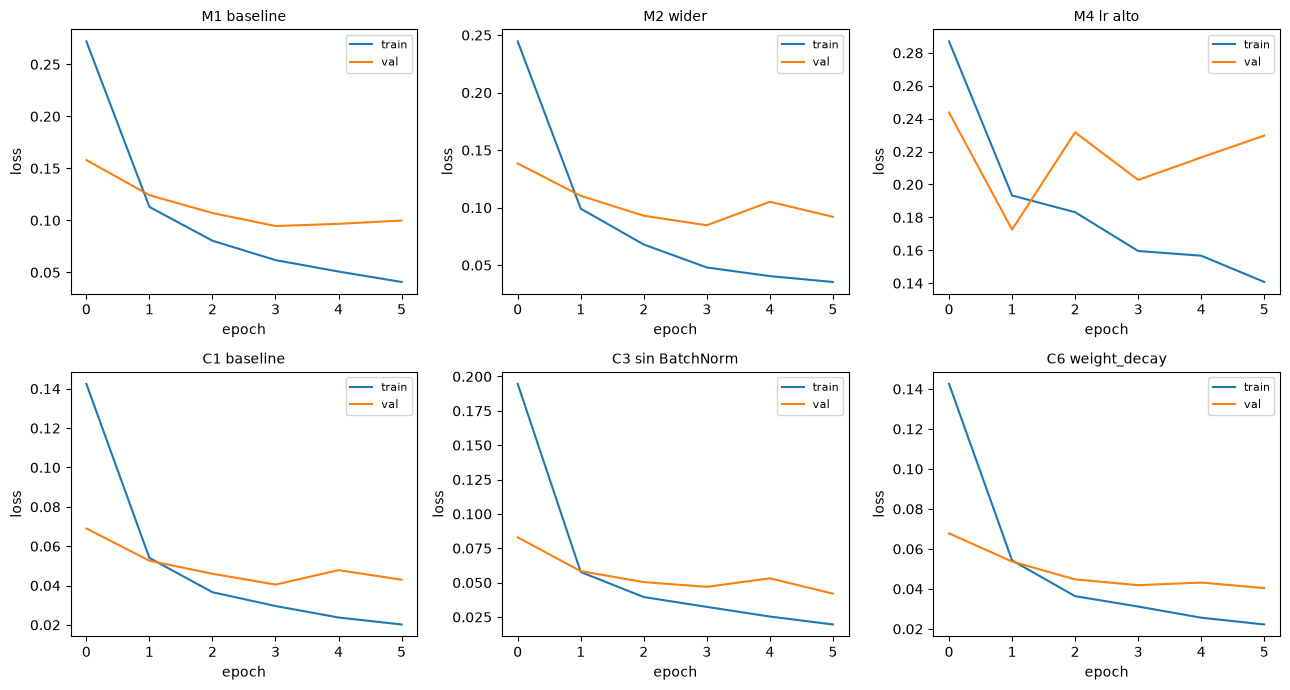

In [22]:
to_plot = ["M1 baseline", "M2 wider", "M4 lr alto", "C1 baseline", "C3 sin BatchNorm", "C6 weight_decay"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, cid in zip(axes.flat, to_plot):
    r = next(r for r in results if r["id"] == cid)
    h = r["history"]
    ax.plot(h["train_loss"], label="train")
    ax.plot(h["val_loss"], label="val")
    ax.set_title(cid, fontsize=10)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Lectura de las curvas:** se completa en el Batch 6 (Discusión y análisis), una vez
disponibles los resultados finales de test.

### Selección de la mejor configuración por arquitectura

In [23]:
best_mlp = max([r for r in results if r["arch"] == "mlp"], key=lambda r: r["val_accuracy"])
best_cnn = max([r for r in results if r["arch"] == "cnn"], key=lambda r: r["val_accuracy"])
print("Mejor MLP:", best_mlp["id"], "-> val_accuracy =", round(best_mlp["val_accuracy"], 4))
print("Mejor CNN:", best_cnn["id"], "-> val_accuracy =", round(best_cnn["val_accuracy"], 4))

Mejor MLP: M1 baseline -> val_accuracy = 0.9732
Mejor CNN: C6 weight_decay -> val_accuracy = 0.9883
